# SOCIAL NETWORK ANALYSIS: CORSO INTRODUTTIVO

### TC CSArs Calanna

In [1]:
# importa librerie
import random
import numpy as np
import pandas as pd
import networkx as nx
from itertools import permutations, combinations
import networkx.algorithms.connectivity as nxconn
from networkx.algorithms import community as nxcomm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# personlizza pandas
pd.set_option('display.max_columns', None)

In [2]:
# opzioni di base
FIG_SIZE = (10,8)
NODE_SIZE=450
SEED = 42
K_VALUE = .2

BASE_OPTIONS = {
    "node_size": NODE_SIZE,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}

NODE_OPTIONS = {
    "node_size": NODE_SIZE,
    "node_color": "white",
    "edgecolors": "black",
}

In [3]:
# carica da file esterno
random.seed(SEED)
Ge = nx.read_edgelist("Ge.edgelist")
spring_pos = nx.spring_layout(Ge, k=K_VALUE, seed=SEED)
circular_pos = nx.circular_layout(Ge)

# 1. ESERCITAZIONE

L'analisi delle reti sociali (SNA) indaga le strutture sociali attraverso la teoria dei grafi. La SNA caratterizza i gruppi sociali in termini di nodi (persone) e di collegamenti tra nodi (relazioni, interazioni). Quanto segue è un'introduzione minima ai concetti della SNA descrittiva e, in particolare, alle misure quantitative che saranno usate per analizzare le "interviste di gruppo". 

## 1.1 ELEMENTI DI BASE

Una rete è un sistema di elementi collegati tra loro

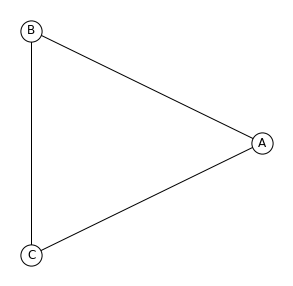

In [4]:
# ESEMPIO DI UNDIRECTED NETWORK (NETWORK NON ORIENTATO)
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

alpha = "ABCA"
nodes = [(x, alpha[idx+1]) for idx, x in enumerate(alpha[:-1])]

Gu = nx.Graph()
Gu.add_edges_from(nodes)
pos = nx.circular_layout(Gu)
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax);

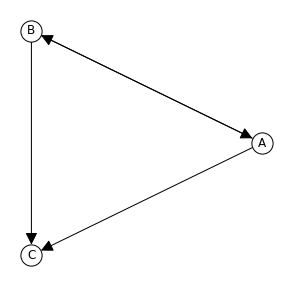

In [5]:
# ESEMPIO DI DIRECTED NETWORK (NETWORK ORIENTATO)
fig, ax = plt.subplots(figsize=(5,5))
ax.axis('off')

alpha = "ABC"
nodes = list(permutations(alpha,2))

Gd = nx.DiGraph()
Gd.add_edges_from(nodes[:-2])
pos = nx.circular_layout(Gd)
options = dict(**BASE_OPTIONS)
options.update({ "arrowsize": 25 })
nx.draw_networkx(Gd, pos, **options, ax=ax);

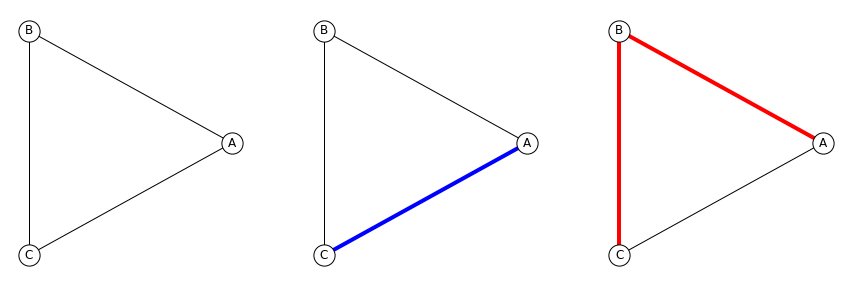

In [6]:
# ESEMPI DI PERCORSO
# (il percorso più breve tra due nodi si chiama geodetica)
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(15,5), nrows=1, ncols=3)

for ax in (ax1, ax2, ax3):
    ax.axis('off')
    
# output network
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax1)
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax2)
nx.draw_networkx_edges(Gu, pos, edgelist=[("A","C")], edge_color="b", width=4, ax=ax2)
nx.draw_networkx(Gu, pos, **BASE_OPTIONS, ax=ax3);
nx.draw_networkx_edges(Gu, pos, edgelist=[("A","B"),("B","C")], edge_color="r", width=4, ax=ax3);

## 1.2 MESO-STRUTTURE

In [7]:
# carica da file esterno
Gi = nx.read_edgelist("Gi.edgelist")
pos= nx.spring_layout(Gi, k=K_VALUE, seed=SEED)

### 1.2.1 Triangolo

A triangle consists of a closed triplet of nodes.

[['A', 'B', 'D'],
 ['A', 'D', 'F'],
 ['B', 'D', 'E'],
 ['B', 'D', 'G'],
 ['B', 'E', 'G'],
 ['D', 'F', 'G'],
 ['D', 'E', 'G'],
 ['F', 'G', 'H']]

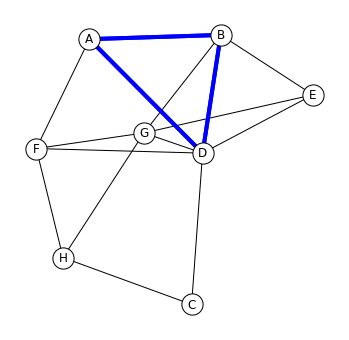

In [8]:
# TUTTI I TRIANGOLI
all_cliques = list(nx.enumerate_all_cliques(Gi))
triangles = [clq for clq in all_cliques if len(clq) == 3]
display(triangles)

fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

# output network
nx.draw_networkx(Gi, pos, **BASE_OPTIONS, ax=ax)
edges = list(permutations(triangles[0], 2))
nx.draw_networkx_edges(Gi, pos, edgelist=edges, edge_color="b", width=4, ax=ax);

### 1.2.2 CLIQUE

A clique is a subset of vertices of an undirected graph such that every two distinct vertices in the clique are adjacent. That is, a clique of a graph G is an induced subgraph of G that is complete.

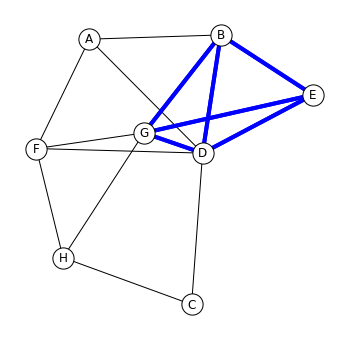

In [9]:
# CLIQUE MASSIMA
max_clique = list(nx.enumerate_all_cliques(Gi))[-1]

fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

# output network
nx.draw_networkx(Gi, pos, **BASE_OPTIONS, ax=ax)
edges = list(permutations(max_clique, 2))
nx.draw_networkx_edges(Gi, pos, edgelist=edges, edge_color="b", width=4, ax=ax);

### 1.2.3 K-CORE

A k-core of a network is a subgraph in which each node has at least k connections to other nodes in the subgraph.

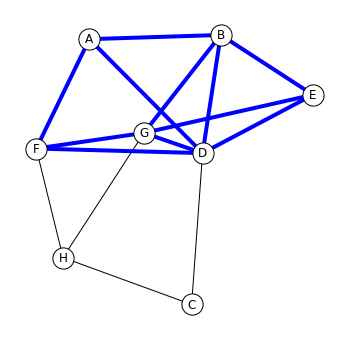

In [10]:
# K-CORE CON K=3
fig, ax = plt.subplots(figsize=(6,6))
ax.axis('off')

# output network
nx.draw_networkx(Gi, pos, **BASE_OPTIONS, ax=ax)
edges = nx.algorithms.core.k_core(Gi, 3).edges()
nx.draw_networkx_edges(Gi, pos, edgelist=edges, edge_color="b", width=4, ax=ax);

## 1.3 VISUALIZZAZIONE DEL NETWORK

### 1.3.1 LAYOUT CIRCOLARE

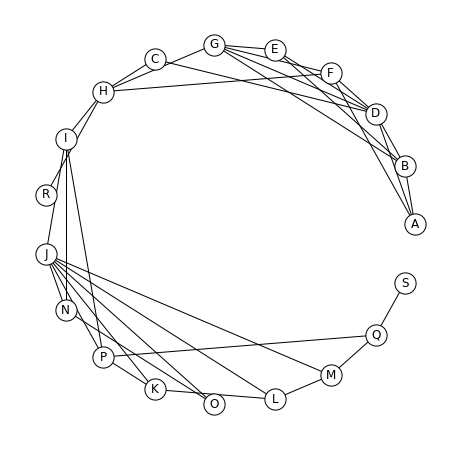

In [11]:
# VISUALIZZAZIONE LAYOUT CIRCOLARE
fig, ax = plt.subplots(figsize=(8,8))
ax.axis('off')

# output network
nx.draw_networkx(Ge, pos=circular_pos, **BASE_OPTIONS, ax=ax)

### 1.3.2 LAYOUT FORCE-DIRECTED (CAMPO DI FORZA)

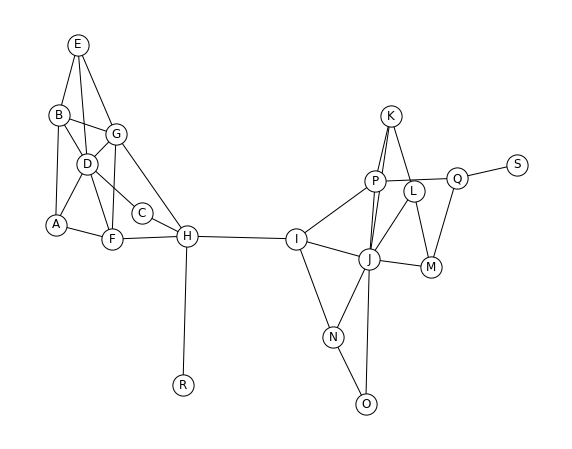

In [12]:
# VISUALIZZAZIONE FORCE-DIRECTED (CAMPO DI FORZA)
def plot_network():
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.axis('off')

    # output network
    nx.draw_networkx(Ge, pos=spring_pos,**BASE_OPTIONS, ax=ax)
    return fig, ax

plot_network();

### 1.3.3 LAYOUT FORCE-DIRECTED WEIGHTED

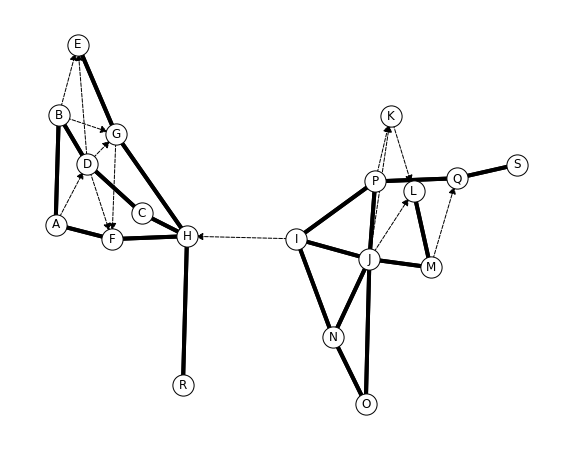

In [54]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.axis('off')

L = Ge.to_directed()
for (s,t) in random.choices(list(L.edges()), k=20):
    if (s,t) in L.edges and (t,s) in L.edges : L.remove_edge(s,t)
reciprical_edges = [ (s,t) for (s,t) in L.edges if (t,s) in L.edges ]
non_reciprocal_edges = [ e for e in L.edges if e not in reciprical_edges]
loc = nx.spring_layout(L, k=.8, seed=SEED)
nx.draw_networkx_nodes(L,spring_pos, **NODE_OPTIONS, ax=ax);
nx.draw_networkx_edges(L,spring_pos, edgelist = non_reciprocal_edges, style="--", arrowsize=15);
nx.draw_networkx_edges(L,spring_pos, edgelist = reciprical_edges, width=4, arrowstyle="-");
nx.draw_networkx_labels(L,spring_pos);

## 1.4 DESCRITTIVE: macro-struttura

### 1.4.1 Diameter
the diameter of a connected graph is the maximum length of a shortest path. That is, it is the maximum of the distances between pairs of vertices in the graph. If the graph has weights on its edges, then its weighted diameter measures path length by the sum of the edge weights along a path, while the unweighted diameter measures path length by the number of edges. For disconnected graphs, definitions vary: the diameter may be defined as infinite, or as the largest diameter of a connected component, or it may be undefined.

In [14]:
# DIAMETRO -- GEODETICA PIU' LUNGA
f"diametro del network: {nx.diameter(Ge)}"

'diametro del network: 6'

In [15]:
# LUNGHEZZA GEODETICHE TRA NODI
df = pd.DataFrame(nx.shortest_path(Ge)).applymap(lambda x: len(x))
df = df.applymap(lambda x: x-1)
df = df.reindex(sorted(df.columns), axis=1).sort_index()
df.style.highlight_max(color = 'lightgreen', axis=1)

,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S
A,0,1,2,1,2,1,2,2,3,4,5,5,5,4,5,4,5,3,6
B,1,0,2,1,1,2,1,2,3,4,5,5,5,4,5,4,5,3,6
C,2,2,0,1,2,2,2,1,2,3,4,4,4,3,4,3,4,2,5
D,1,1,1,0,1,1,1,2,3,4,5,5,5,4,5,4,5,3,6
E,2,1,2,1,0,2,1,2,3,4,5,5,5,4,5,4,5,3,6
F,1,2,2,1,2,0,1,1,2,3,4,4,4,3,4,3,4,2,5
G,2,1,2,1,1,1,0,1,2,3,4,4,4,3,4,3,4,2,5
H,2,2,1,2,2,1,1,0,1,2,3,3,3,2,3,2,3,1,4
I,3,3,2,3,3,2,2,1,0,1,2,2,2,1,2,1,2,2,3
J,4,4,3,4,4,3,3,2,1,0,1,1,1,1,1,1,2,3,3


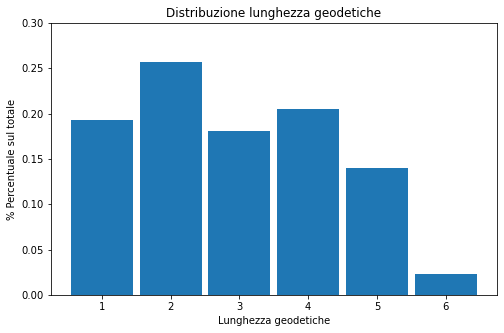

In [16]:
# VISUALIZZA DISTRIBUZIONE LUNGHEZZA DELLE GEODETICHE
fig, ax = plt.subplots(figsize=(8,5))

# dict lunghezza geodetiche
dict_shortest = dict(nx.shortest_path_length(Ge))

# appittisci dict geodetiche
flattened_shortest = sum(map(lambda x: list(x.values()), dict_shortest.values()), [])
flattened_shortest = [x for x in flattened_shortest if x > 0]

# geodetica più lunga
high = max(flattened_shortest)

# output grafico
bins = [0.5 + i for i in range(high + 1)]
g = ax.hist(flattened_shortest, bins=bins, rwidth=.9, density=True)
ax.set_title("Distribuzione lunghezza geodetiche")
ax.set_xlabel("Lunghezza geodetiche")
ax.set_ylabel("% Percentuale sul totale")
ax.set_ylim(0,.3);

In [17]:
# GEODETCA TRA A ED S
list(nx.all_shortest_paths(Ge,"A","S"))

[['A', 'F', 'H', 'I', 'P', 'Q', 'S']]

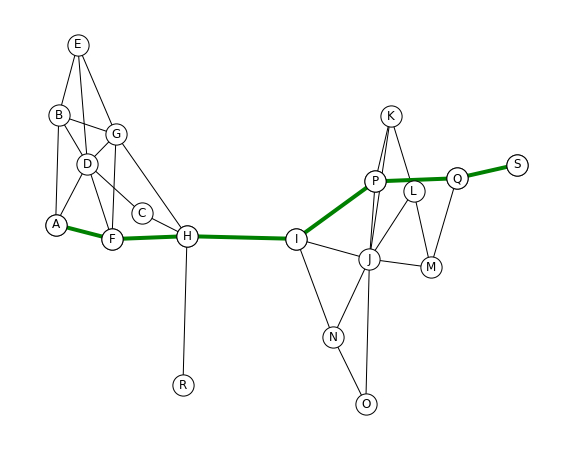

In [18]:
# VISUALIZZA GEODETICA TRA A ED S
fig, ax = plot_network()

possible_sps = list(nx.all_shortest_paths(Ge, "A", "S"))
first_sp = possible_sps[0]
first_sp_edges = [ (x, first_sp[idx+1]) for idx,x in enumerate(first_sp[:-1]) ]

nx.draw_networkx_nodes(Ge, pos=spring_pos, nodelist=first_sp, **NODE_OPTIONS, ax=ax)
nx.draw_networkx_edges(Ge, pos=spring_pos, edgelist=first_sp_edges, edge_color="g", width=4, ax=ax);

In [19]:
# GEODETICHE TRA A ED O (PIU' DI UNA)
list(nx.all_shortest_paths(Ge, "A", "O"))

[['A', 'F', 'H', 'I', 'J', 'O'], ['A', 'F', 'H', 'I', 'N', 'O']]

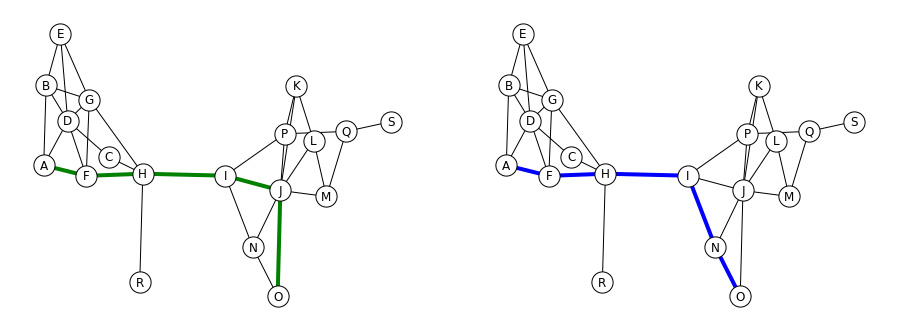

In [20]:
# VISUALIZZA GEODETICHE TRA A ED O

fig, (ax1, ax2) = plt.subplots(figsize=(13,5), nrows=1, ncols=2)
fig.tight_layout()

for ax in (ax1, ax2):
    ax.axis('off')

# calcola tutte le possibili geodetiche
possible_sps = list(nx.all_shortest_paths(Ge, "A", "O"))

# scegli prima geodetica
first_sp = possible_sps[0]
first_sp_edges = [ (x, first_sp[idx+1]) for idx, x in enumerate(first_sp[:-1]) ]
# scegli seconda geodetica
second_sp = possible_sps[1]
second_sp_edges = [ (x, second_sp[idx+1]) for idx, x in enumerate(second_sp[:-1]) ]

# output grafico
nx.draw_networkx(Ge, pos=spring_pos, **NODE_OPTIONS, ax=ax1)
nx.draw_networkx(Ge, pos=spring_pos, **NODE_OPTIONS, ax=ax2)
nx.draw_networkx_edges(Ge, pos=spring_pos, edgelist=first_sp_edges, edge_color="g", width=4, ax=ax1)
nx.draw_networkx_edges(Ge, pos=spring_pos, edgelist=second_sp_edges, edge_color="b", width=4, ax=ax2);

### 1.4.2 DENSITY
In a graph of n nodes, the density is the ratio of the number of edges of the graph to the number of edges in a complete graph on n nodes.

In [21]:
density = nx.density(Ge)
f"density: {np.round(density,2)}"

'density: 0.19'

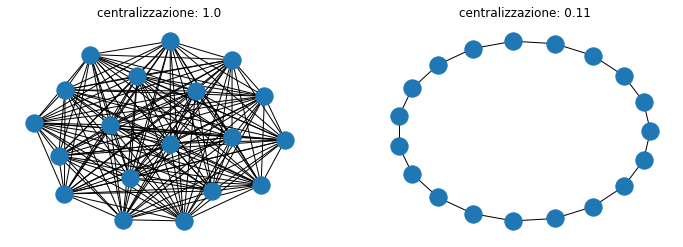

In [22]:
# ESEMPIO DI DENSITA' MASSIMA E MINIMA
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

S = nx.complete_graph(19)
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"centralizzazione: {nx.density(S)}")

C = nx.Graph()
nodes = range(19)
C.add_nodes_from(nodes)
C.add_edges_from(
    sum([[(x,nodes[idx+1]) for idx,x in enumerate(nodes[:-1])], [(nodes[0], nodes[-1])]], [])
)
loc = nx.circular_layout(C)
nx.draw(C,loc, ax=ax2)
ax2.set_title(f"centralizzazione: {np.round(nx.density(C),2)}");

### 1.4.3 CENTRALIZATION

The Centralization coefficient expresses how much a network is organized around focal points.

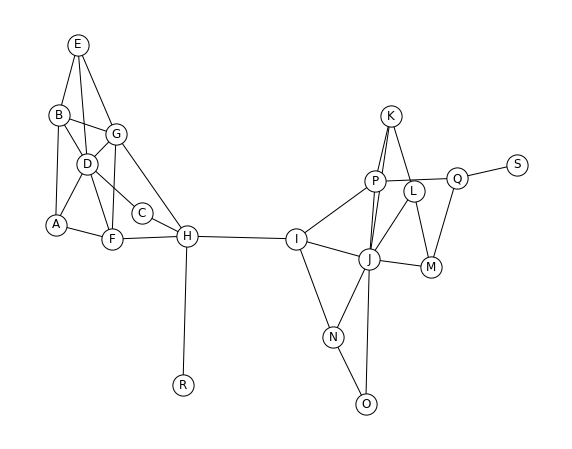

In [23]:
fig, ax = plot_network()

In [24]:
def get_centralization(G):
    n = G.order()
    centrality_values = dict(G.degree()).values()
    c_max = max(centrality_values)
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))

f"Centralizzazione: {np.round(get_centralization(Ge),2)}"

'Centralizzazione: 0.22'

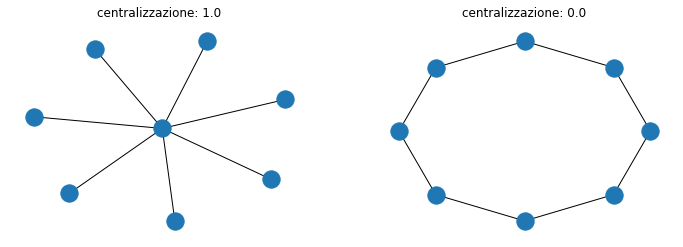

In [25]:
# ESEMPIO DI CENTRALIZATION MASSIMA E MINIMA
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

S = nx.Graph()
S.add_nodes_from(range(8))
nx.add_star(S, S.nodes())
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"centralizzazione: {get_centralization(S)}")

C = C = nx.watts_strogatz_graph(8, 2, 0)
loc = nx.circular_layout(C)
nx.draw(C,loc, ax=ax2)
ax2.set_title(f"centralizzazione: {get_centralization(C)}");

### 1.4.4 TRANSITIVITY

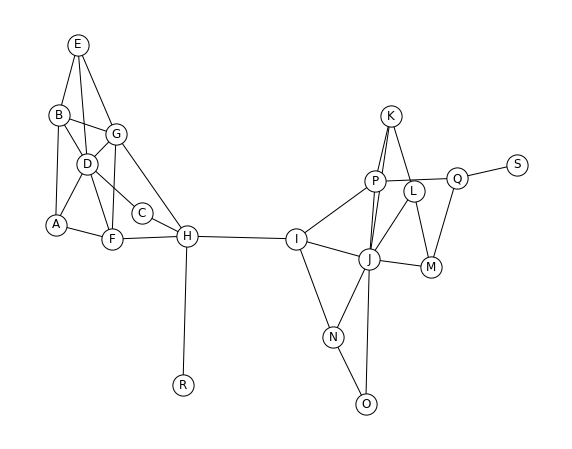

In [26]:
fig, ax = plot_network()

In [27]:
f"transitivity: {np.round(nx.transitivity(Gi),2)}"

'transitivity: 0.51'

4.6571428571428575

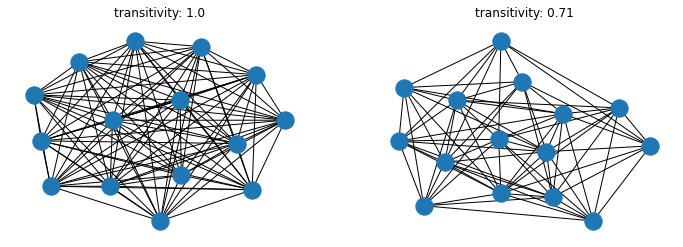

In [28]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

S = nx.complete_graph(15)
loc = nx.spring_layout(S)
nx.draw(S,loc, ax=ax1)
ax1.set_title(f"transitivity: {np.round(nx.transitivity(S),2)}")

C = nx.watts_strogatz_graph(15, 10, 0.4, seed=42)
loc = nx.spring_layout(C)
nx.draw(C,loc,ax=ax2)
ax2.set_title(f"transitivity: {np.round(nx.transitivity(C),2)}");

sum(nx.triangles(C).values()) / len(list(combinations(C,2)))

## 2.3 DESCRITTIVE: micro-strutture

### 2.3.1 Degree cenrality 

The number of links incident upon a node (i.e., the number of ties that a node has)

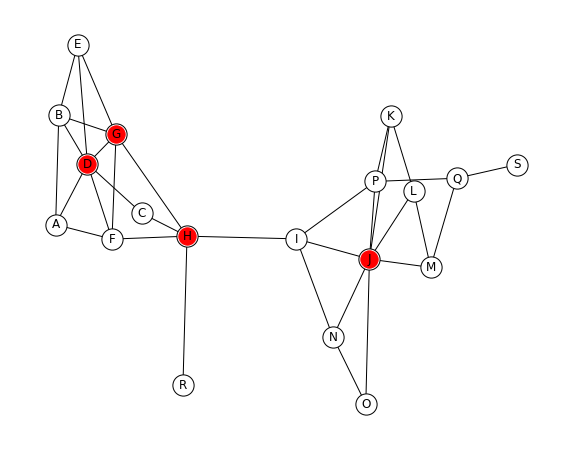

In [29]:
highest_dc = [ n for n,v in sorted(list(nx.degree(Ge)), key=lambda e: e[1], reverse=True)][:4]
f"I 10 nodi con più alta dc: {highest_dc}"

fig, ax = plot_network();
ax.axis('off')
nx.draw_networkx_nodes(Ge, pos=spring_pos, nodelist=highest_dc, node_color="r", edgecolors="r");

<b>Bridge</b>:  a bridge, isthmus, cut-edge, or cut arc is an edge of a graph whose deletion increases the graph's number of connected components.

In [30]:
bridges = list(nx.bridges(G))
f"bridges: {bridges}"

NameError: name 'G' is not defined

In [ ]:
# proof
G_clone = G.copy()
cc_before = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_before}")
G_clone.remove_edge(*bridges[0])
cc_after = len(list(nx.connected_components(G_clone)))
display(f"connected components before bridge removal: {cc_after}")